# Transportation Frequency and Employment Status

Rachel Rapier (University of Wisconsin, Madison)  
October 15, 2025

This manuscript discusses the relationship between public transportation and rideshare frequency based on employment status and whether the individual had access to a vehicle.

# Introduction:

The type of transportation an individual chooses to use is influenced by a variety of factors, including employment status and access to a vehicle.

A full-time employee working in the office will have to be in the office 20-22 days per month, while part-time employees, contract employees, and retirees will not need to commute as frequently. Because full time employees are required to be somewhere more days of the week than other types of employment, I hypothesize that the sum of their total public transportation days per month and rideshare days per month will be higher than those who are not full-time employed. I also hypothesize that access to a vehicle will decrease the total number of public transportaion and rideshare rides. I hypothesize that access to a vehicle will have a stronger effect on the number of public transportation and rideshare rides for individuals not employed full-time.

Full time employees may have more disposable income to afford a vehicle. Others may rely sol

Transportation use and frequency varies based on num between full-time employed individuals and those who are not employed full-time. In this study, I examine public transportation and rideshare usage patterns between these two groups.

In addition, having access to a vehicle can impact transportation choices, and I hypothesize that access to a vehicle will decrease the \# of days per month that individuals use public transportation or rideshare services.

# Data and Methods

### Standard Package Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import statsmodels.api as sm
from statsmodels.formula.api import ols
from collections import defaultdict

sns.set_context('talk')

dataA = pd.read_csv('data_orig/PRCAProlificExport_FileA.csv')
dataB = pd.read_csv('data_orig/PRCAProlificExport_FileB.csv')
dataC = pd.read_csv('data_orig/PRCAQualtricsExport_FileC.csv')

questions = pd.read_csv('data_dictionary.csv')


# rename the columns to variable_name and question
questions.rename(columns={questions.columns[0]: 'variable_name', questions.columns[1]: 'question'}, inplace=True)

# merge dataframes
data_all = pd.merge(dataA, dataB, how = 'outer')

# Then merge the result with dataC (Q0 in dataC contains Participant id that matches Participant id in dataA/dataB)
data_all = pd.merge(data_all, dataC, left_on='Participant id', right_on='Q0', how='right')

### Data Cleaning

I created a new particpant ID as an index that was simplified from the original dataset. This was done to make the data easier to work with and to avoid issues with the long string of numbers in the original participant ID.

I then dropped the columns in the data set that I was not using for my analysis.

There were 2 participants that completed the survey in less than 30 seconds, so I dropped them from the dataset because their values would not be accurate.

In [2]:
#create an indexing column because participant id a long string of numbers and we want to simplify it. This index will be used as the participant id. Then move it to the first column

data_all['p_id'] = data_all.index
data_all = data_all[['p_id'] + [col for col in data_all.columns if col != 'p_id']]

#drop columns that are not needed   
df = data_all.drop(columns=['EndDate', 'StartDate', 'LocationLatitude', 'LocationLongitude', 'Started at', 'Completed at', 'ResponseId', 'Participant id', 'Submission id', 'Total approvals', 'Sex', 'Country of residence', 'Student status', 'Age'])

#filter for participants that took more than 30 seconds to complete the survey

df = df[df['Duration (in seconds)']> 30]

df = df.drop(columns=['Duration (in seconds)', 'Time taken'])

I converted the rideshare days per month and the public transportation days per month variables into numeric values (0-4) and renamed the columns to be more descriptive. One participant reported ‘Not Sure’ for acess to a vehicle, so I removed them from the data set. Employment status was simplified to a binary variable (full-time or other). I created my dependent variable `total_rides` by summing the rideshare days per month and public transportation days per month variables.

In [3]:
# Get unique values for each Q column (excluding Q0)
q_unique_vals = {}
for col in df.columns:
    if col.startswith('Q') and not col.startswith('Q0'):
        unique_vals = tuple(sorted(df[col].dropna().unique()))
        q_unique_vals[col] = unique_vals

# Group columns by their unique values
value_groups = defaultdict(list)
for col, vals in q_unique_vals.items():
    value_groups[vals].append(col)



group2_mapping = {
  '0-1 days a month': 1, 
  '2-4 days a month': 2, 
  '4-8 days a month': 3, 
  '8 or more days a month': 4, 
  'Never': 0
}
group3_mapping = {
  '1-2 rides in a typical day': 1, 
  '3-4 rides in a typical day': 2, 
  '5-6 rides in a typical day': 3, 
  '7 or more rides in a typical day': 4
}

for col in df.columns:
    if col in value_groups[tuple(sorted(group3_mapping.keys()))]:
        df[col + '_numeric'] = df[col].map(group3_mapping)

for col in df.columns:
    if col in value_groups[tuple(sorted(group2_mapping.keys()))]:
        df[col + '_numeric'] = df[col].map(group2_mapping)

#rename the new numeric columns something that makes more sense
df = df.rename(columns={
  'Q26_numeric': 'public_trans_per_month', 
  'Q27_numeric': 'public_trans_reg_day', 
  'Q28_numeric': 'rideshare_per_month', 
  'Q29_numeric': 'rideshare_reg_day', 
  'Q21':'Car Access'})


#drop ALL Q columns
df = df.drop(columns=[col for col in df.columns if col.startswith('Q')])

#remove 1 participant that has 'Not Sure' as their car access response
df = df[df['Car Access'] != 'Not Sure']

# create a new column called Full-Time that combines Part-Time and Other into Other for Employment Status
df['Full-Time'] = df['Employment status'].apply(lambda x: 'Other' if x in ['Part-Time', 'Other'] else x)

# create my new outcome variable - total rides
df['total_rides'] = df['public_trans_per_month'] + df['rideshare_per_month']


df = df.drop(columns=['public_trans_reg_day', 'rideshare_reg_day'])

# Methods and Data

In [4]:
print(f"Merged dataframe shape: {df.shape}")
print(f"Columns in merged dataframe: {df.columns.tolist()}")

Merged dataframe shape: (270, 7)
Columns in merged dataframe: ['p_id', 'Employment status', 'Car Access', 'public_trans_per_month', 'rideshare_per_month', 'Full-Time', 'total_rides']

In [5]:
# Check for any unreasonable values in the dataset

# Create a mapping of variable names to human-readable descriptions
variable_descriptions = {
    'public_trans_per_month': 'Public Transportation Days per Month',
    'rideshare_per_month': 'Rideshare Days per Month',
    'total_rides': 'Total Ride Days per Month'
}

# Get the descriptive statistics and transpose
desc_stats = df.drop(columns = ['p_id']).describe().transpose().apply(lambda x: round(x, 2))

# Add human-readable descriptions as a new column
desc_stats['Variable'] = desc_stats.index.map(variable_descriptions)

# Drop the existing index and set the new column as the index
desc_stats = desc_stats.reset_index(drop=True).set_index('Variable').drop(columns = ['25%', '50%', '75%'])

desc_stats

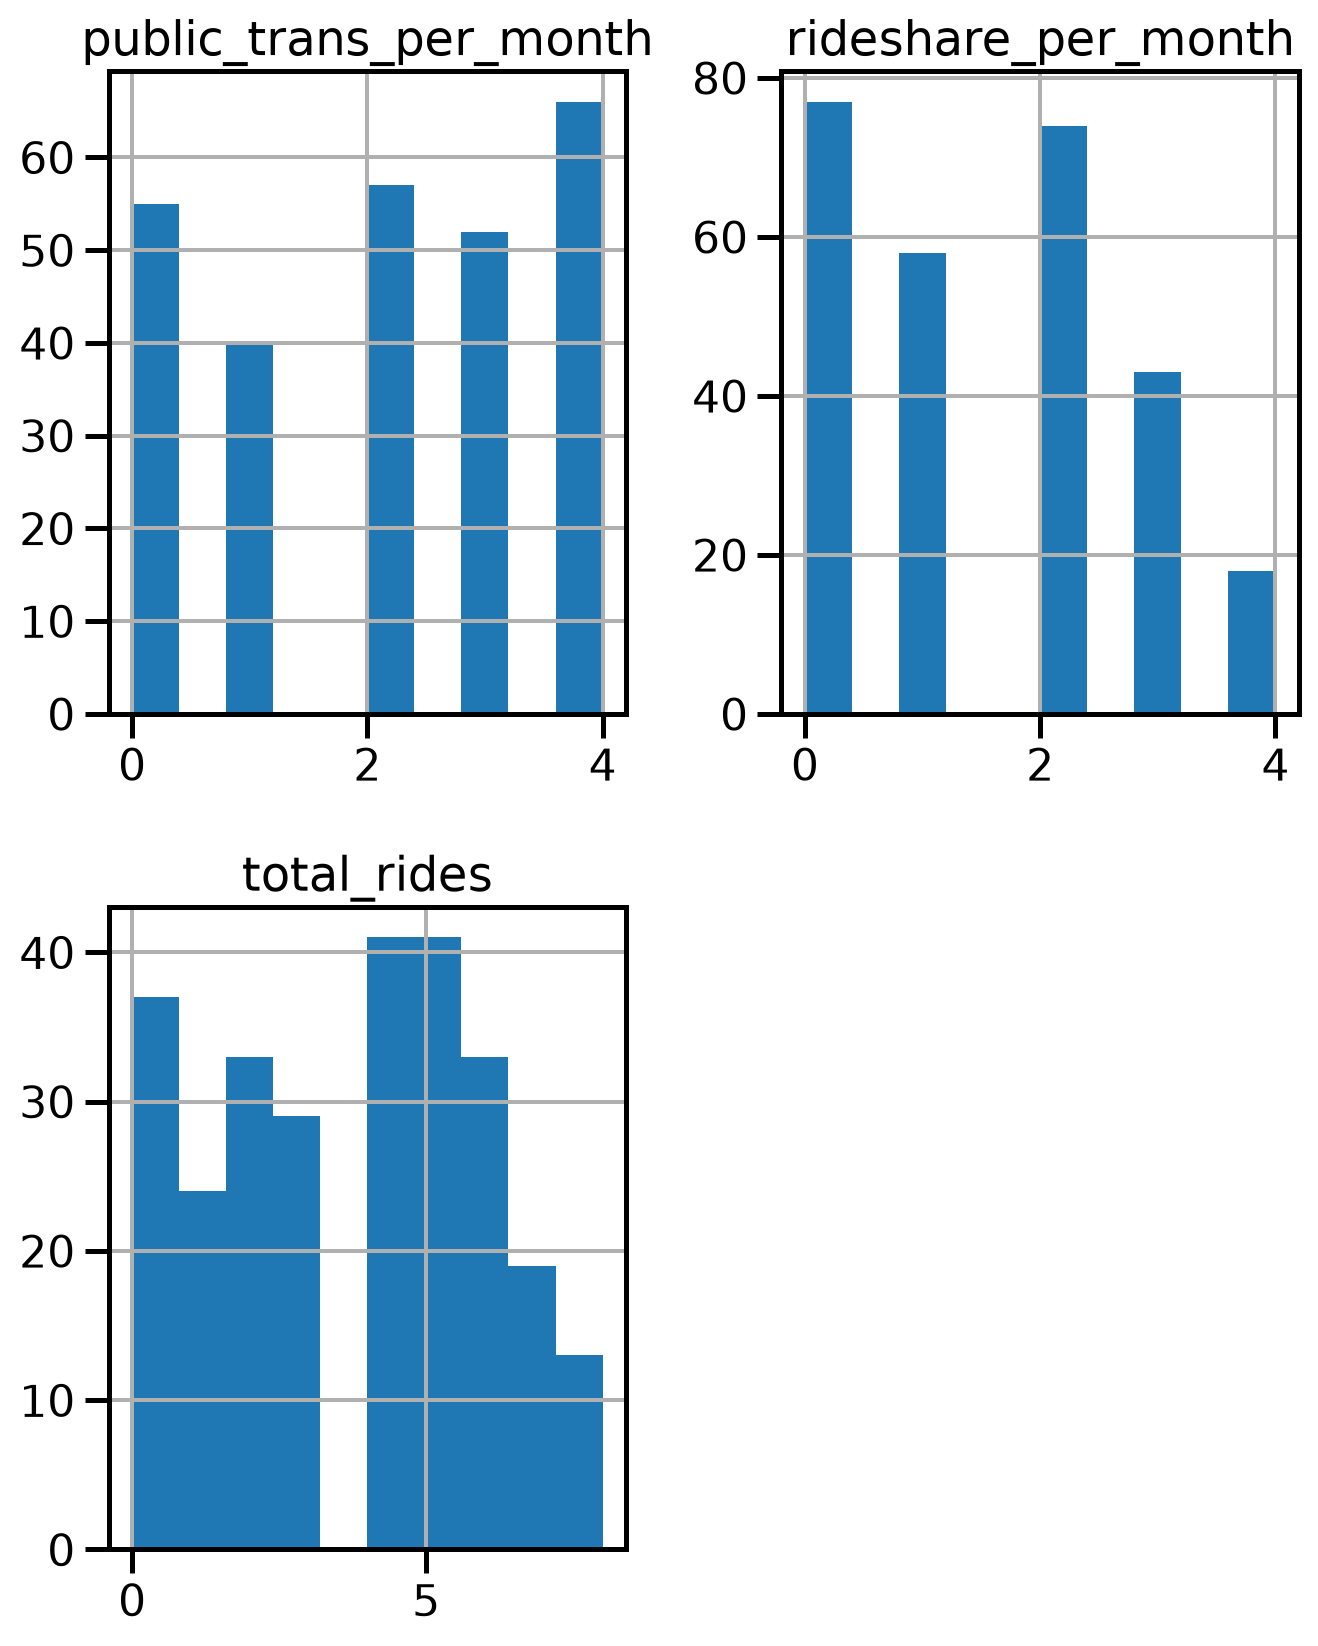

In [6]:
# Drop p_id column
df_plot = df.drop(columns=['p_id'])

df_plot.hist(figsize=(8, 10))
plt.show()

## Employment Status

``` python
# Create a mapping of employment status values to human-readable descriptions
employment_descriptions = {
    'Full-Time': 'Full-Time Employment',
    'Other': 'Other Employment Status'
}

# Get the value counts
employ_counts = df['Full-Time'].value_counts()

# Create a DataFrame with the counts
employ_tbl = pd.DataFrame({'count': employ_counts})

# Add human-readable descriptions as a new column
employ_tbl['Employment'] = employ_tbl.index.map(employment_descriptions)

# Drop the existing index and set the new column as the index
employ_tbl = employ_tbl.reset_index(drop=True).set_index('Employment')

employ_tbl
```

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>

                            count
  ------------------------- -------
  Employment                
  Full-Time Employment      154
  Other Employment Status   97

</div>

## Vehicle Access

``` python
# Create a mapping of car access values to human-readable descriptions
VehicleAccess = {
    'Yes': 'Has Access to Vehicle',
    'No': 'No Access to Vehicle'
}

# Get the value counts
car_counts = df['Car Access'].value_counts()

# Create a DataFrame with the counts
car_tbl = pd.DataFrame({'count': car_counts})

# Add human-readable descriptions as a new column
car_tbl['Vehicle Access'] = car_tbl.index.map(VehicleAccess)

# Drop the existing index and set the new column as the index
car_tbl = car_tbl.reset_index(drop=True).set_index('Vehicle Access')

car_tbl
```

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>

                          count
  ----------------------- -------
  Vehicle Access          
  Has Access to Vehicle   133
  No Access to Vehicle    33

</div>

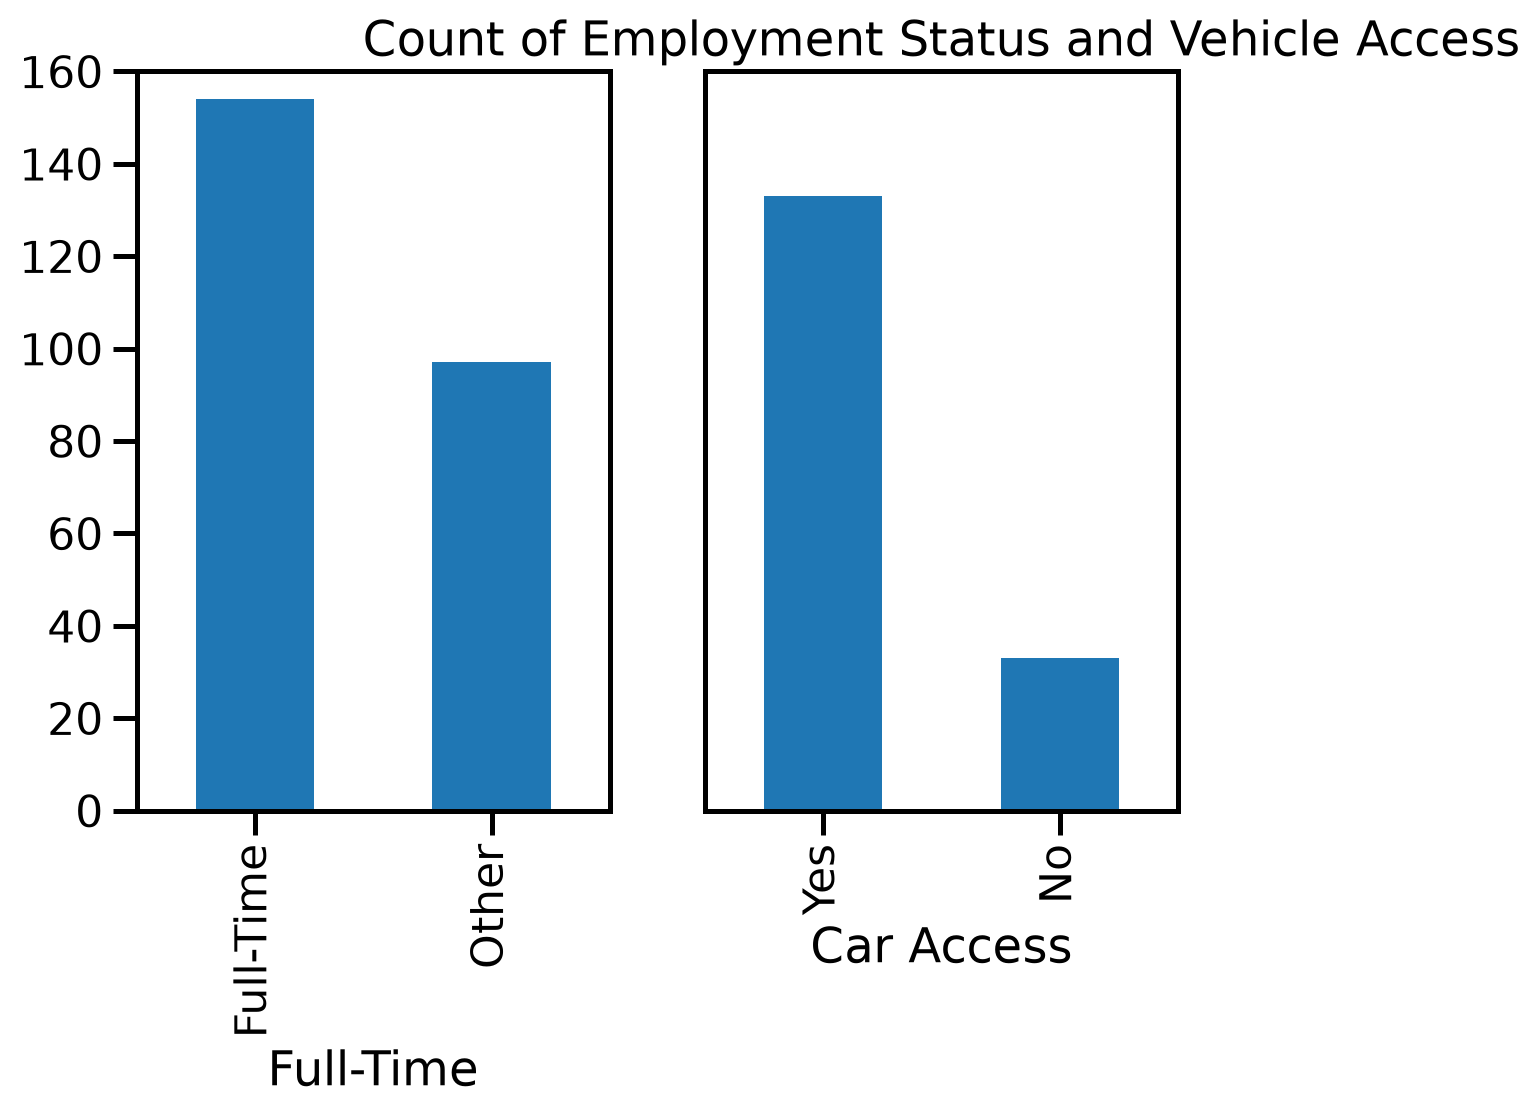

In [9]:
# put value count for employmentstats and for car access in the same figure and make the y axis the same for each plot and don't show the y axis for the 2nd plot
fig, axes = plt.subplots(1, 2)
df['Full-Time'].value_counts().plot(kind='bar', ax=axes[0])
df['Car Access'].value_counts().plot(kind='bar', ax=axes[1])
axes[0].set_ylim([0, 160])
axes[1].set_ylim([0, 160])
axes[1].set_yticks([])   # Remove y-axis ticks for the second plot
axes[1].set_xlabel('Car Access')
plt.title('Count of Employment Status and Vehicle Access')
plt.show()

# Results

In [10]:
cross_tab = df.groupby(['Full-Time', 'Car Access'])['total_rides'].describe().drop(columns = ['25%', '50%', '75%']).round(2)
cross_tab

In [11]:
# Create the ANOVA model (using Q() for column names with special characters)
model = ols('total_rides ~ C(Q("Full-Time")) * C(Q("Car Access"))', data=df).fit()

# Get the ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2).round(2)

# Display the ANOVA table
anova_table

@tbl-describe_dataframe give general descriptive statistics of the numeric values of the data.

@tbl-groupby shows the descriptive statistics of my dependent variable ‘total_rides’ by employment status and vehicle access.

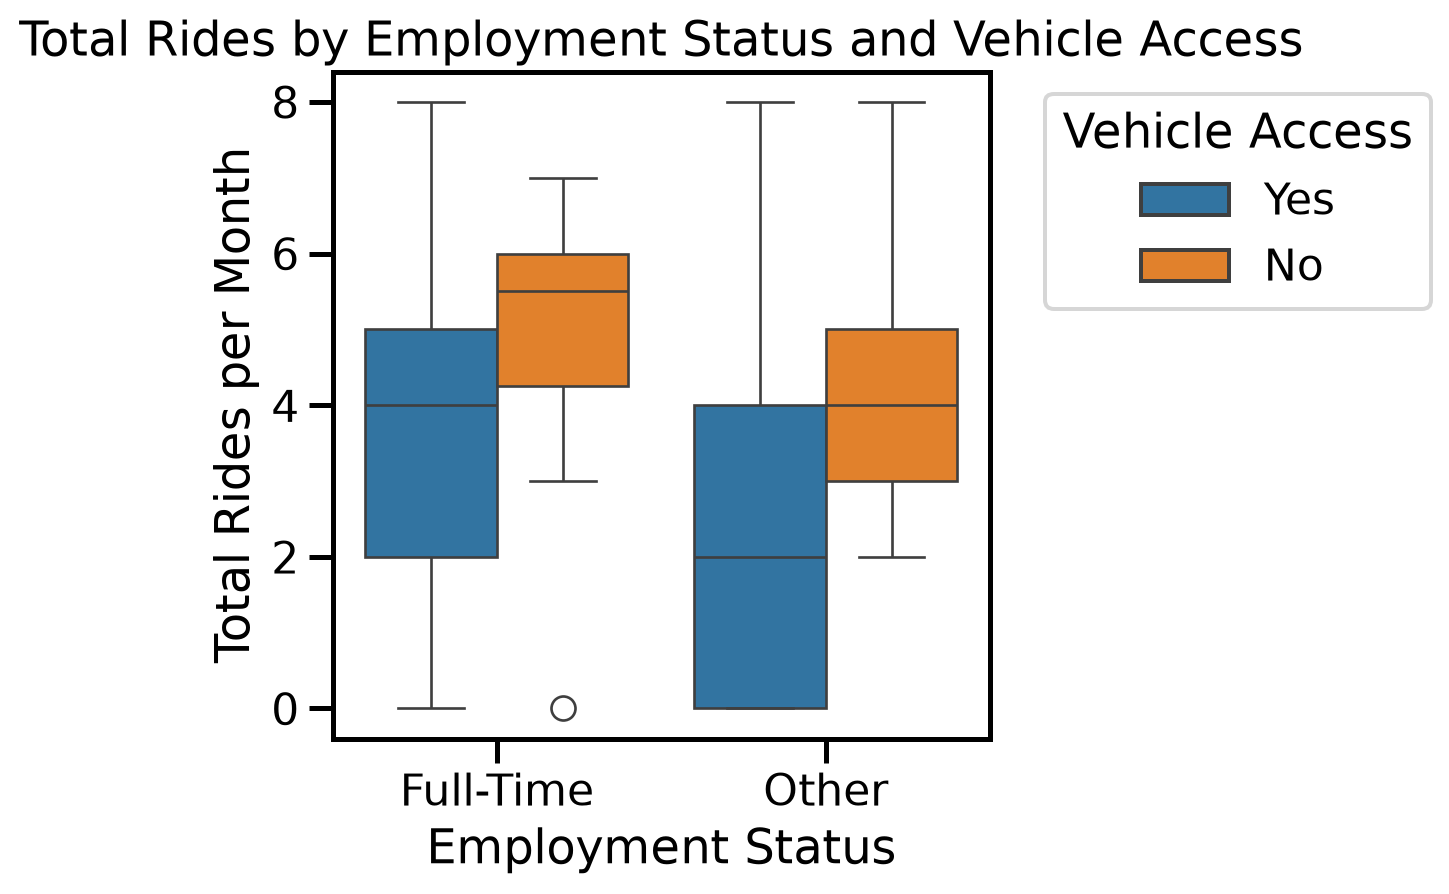

In [12]:
#create a boxplot of total_rides by employment status and vehicle access
sns.boxplot(data=df, x='Full-Time', y='total_rides', hue='Car Access')
plt.title('Total Rides by Employment Status and Vehicle Access')
plt.xlabel('Employment Status')
plt.ylabel('Total Rides per Month')
plt.legend(title='Vehicle Access', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Conclusion, Future Directions, & Limitations

## Future Directions

Reviewing @fig-boxplot, there appears to be an outlier that is a full-time employee without access to a car with very low ride share and public transportation usage days. It would be interesting to further examine this outlier; however, it seems to be this person may walk to work or work from home.

## Limitations

The distributions of the variables(@fig-barplot, @fig-histograms) are not normal, which may impact the results of the ANOVA test.

```` markdown
---
title: "Transportation Frequency and Employment Status"
author: 
  - name: "Rachel Rapier"
    affiliation: "University of Wisconsin, Madison"
date: "2025-10-15"
abstract: |
  This manuscript discusses the relationship between public transportation and rideshare frequency based on employment status and whether the individual had access to a vehicle.
jupyter: python3
bibliography: references.bib
echo: TRUE
---

# Introduction: 

The type of transportation an individual chooses to use is influenced by a variety of factors, including employment status and access to a vehicle. 

A full-time employee working in the office will have to be in the office 20-22 days per month, while part-time employees, contract employees, and retirees will not need to commute as frequently. Because full time employees are required to be somewhere more days of the week than other types of employment, I hypothesize that the sum of their total public transportation days per month and rideshare days per month will be higher than those who are not full-time employed. I also hypothesize that access to a vehicle will decrease the total number of public transportaion and rideshare rides. I hypothesize that access to a vehicle will have a stronger effect on the number of public transportation and rideshare rides for individuals not employed full-time. 

Full time employees may have more disposable income to afford a vehicle. Others may rely sol

Transportation use and frequency varies based on num between full-time employed individuals and those who are not employed full-time. In this study, I examine public transportation and rideshare usage patterns between these two groups. 

In addition, having access to a vehicle can impact transportation choices, and I hypothesize that access to a vehicle will decrease the # of days per month that individuals use public transportation or rideshare services.

# Data and Methods

### Standard Package Imports and Data Loading

quarto-executable-code-5450563D

```python
#| label: load-packages-data
#| 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import statsmodels.api as sm
from statsmodels.formula.api import ols
from collections import defaultdict

sns.set_context('talk')

dataA = pd.read_csv('data_orig/PRCAProlificExport_FileA.csv')
dataB = pd.read_csv('data_orig/PRCAProlificExport_FileB.csv')
dataC = pd.read_csv('data_orig/PRCAQualtricsExport_FileC.csv')

questions = pd.read_csv('data_dictionary.csv')


# rename the columns to variable_name and question
questions.rename(columns={questions.columns[0]: 'variable_name', questions.columns[1]: 'question'}, inplace=True)

# merge dataframes
data_all = pd.merge(dataA, dataB, how = 'outer')

# Then merge the result with dataC (Q0 in dataC contains Participant id that matches Participant id in dataA/dataB)
data_all = pd.merge(data_all, dataC, left_on='Participant id', right_on='Q0', how='right')

```


### Data Cleaning

I created a new particpant ID as an index that was simplified from the original dataset. This was done to make the data easier to work with and to avoid issues with the long string of numbers in the original participant ID.

I then dropped the columns in the data set that I was not using for my analysis.

There were 2 participants that completed the survey in less than 30 seconds, so I dropped them from the dataset because their values would not be accurate.


quarto-executable-code-5450563D

```python
#| label: cleaning-data

#create an indexing column because participant id a long string of numbers and we want to simplify it. This index will be used as the participant id. Then move it to the first column

data_all['p_id'] = data_all.index
data_all = data_all[['p_id'] + [col for col in data_all.columns if col != 'p_id']]

#drop columns that are not needed   
df = data_all.drop(columns=['EndDate', 'StartDate', 'LocationLatitude', 'LocationLongitude', 'Started at', 'Completed at', 'ResponseId', 'Participant id', 'Submission id', 'Total approvals', 'Sex', 'Country of residence', 'Student status', 'Age'])

#filter for participants that took more than 30 seconds to complete the survey

df = df[df['Duration (in seconds)']> 30]

df = df.drop(columns=['Duration (in seconds)', 'Time taken'])

```


I converted the rideshare days per month and the public transportation days per month variables into numeric values (0-4) and renamed the columns to be more descriptive. One participant reported 'Not Sure' for acess to a vehicle, so I removed them from the data set. Employment status was simplified to a binary variable (full-time or other). I created my dependent variable `total_rides` by summing the rideshare days per month and public transportation days per month variables.

quarto-executable-code-5450563D

```python
#| label: map-numeric-values
#| 


# Get unique values for each Q column (excluding Q0)
q_unique_vals = {}
for col in df.columns:
    if col.startswith('Q') and not col.startswith('Q0'):
        unique_vals = tuple(sorted(df[col].dropna().unique()))
        q_unique_vals[col] = unique_vals

# Group columns by their unique values
value_groups = defaultdict(list)
for col, vals in q_unique_vals.items():
    value_groups[vals].append(col)



group2_mapping = {
  '0-1 days a month': 1, 
  '2-4 days a month': 2, 
  '4-8 days a month': 3, 
  '8 or more days a month': 4, 
  'Never': 0
}
group3_mapping = {
  '1-2 rides in a typical day': 1, 
  '3-4 rides in a typical day': 2, 
  '5-6 rides in a typical day': 3, 
  '7 or more rides in a typical day': 4
}

for col in df.columns:
    if col in value_groups[tuple(sorted(group3_mapping.keys()))]:
        df[col + '_numeric'] = df[col].map(group3_mapping)

for col in df.columns:
    if col in value_groups[tuple(sorted(group2_mapping.keys()))]:
        df[col + '_numeric'] = df[col].map(group2_mapping)

#rename the new numeric columns something that makes more sense
df = df.rename(columns={
  'Q26_numeric': 'public_trans_per_month', 
  'Q27_numeric': 'public_trans_reg_day', 
  'Q28_numeric': 'rideshare_per_month', 
  'Q29_numeric': 'rideshare_reg_day', 
  'Q21':'Car Access'})


#drop ALL Q columns
df = df.drop(columns=[col for col in df.columns if col.startswith('Q')])

#remove 1 participant that has 'Not Sure' as their car access response
df = df[df['Car Access'] != 'Not Sure']

# create a new column called Full-Time that combines Part-Time and Other into Other for Employment Status
df['Full-Time'] = df['Employment status'].apply(lambda x: 'Other' if x in ['Part-Time', 'Other'] else x)

# create my new outcome variable - total rides
df['total_rides'] = df['public_trans_per_month'] + df['rideshare_per_month']


df = df.drop(columns=['public_trans_reg_day', 'rideshare_reg_day'])

```





# Methods and Data

quarto-executable-code-5450563D

```python
#| label: new_merged_data_info

print(f"Merged dataframe shape: {df.shape}")
print(f"Columns in merged dataframe: {df.columns.tolist()}")

```


quarto-executable-code-5450563D

```python
#| label: tbl-describe_dataframe
#| tbl-cap: "Descriptive statistics for the cleaned dataset"
# Check for any unreasonable values in the dataset

# Create a mapping of variable names to human-readable descriptions
variable_descriptions = {
    'public_trans_per_month': 'Public Transportation Days per Month',
    'rideshare_per_month': 'Rideshare Days per Month',
    'total_rides': 'Total Ride Days per Month'
}

# Get the descriptive statistics and transpose
desc_stats = df.drop(columns = ['p_id']).describe().transpose().apply(lambda x: round(x, 2))

# Add human-readable descriptions as a new column
desc_stats['Variable'] = desc_stats.index.map(variable_descriptions)

# Drop the existing index and set the new column as the index
desc_stats = desc_stats.reset_index(drop=True).set_index('Variable').drop(columns = ['25%', '50%', '75%'])

desc_stats
```


quarto-executable-code-5450563D

```python
#| label: fig-histograms
#| fig-cap: "Histograms of numeric variables"

# Drop p_id column
df_plot = df.drop(columns=['p_id'])

df_plot.hist(figsize=(8, 10))
plt.show()
```

::: {.panelset}

::: {.panel}
## Employment Status

quarto-executable-code-5450563D

```python
#| label: tbl-valuecounts-employment
#| tbl-cap: "Value counts for employment status"

# Create a mapping of employment status values to human-readable descriptions
employment_descriptions = {
    'Full-Time': 'Full-Time Employment',
    'Other': 'Other Employment Status'
}

# Get the value counts
employ_counts = df['Full-Time'].value_counts()

# Create a DataFrame with the counts
employ_tbl = pd.DataFrame({'count': employ_counts})

# Add human-readable descriptions as a new column
employ_tbl['Employment'] = employ_tbl.index.map(employment_descriptions)

# Drop the existing index and set the new column as the index
employ_tbl = employ_tbl.reset_index(drop=True).set_index('Employment')

employ_tbl
```

:::

::: {.panel}
## Vehicle Access

quarto-executable-code-5450563D

```python
#| label: tbl-valuecounts-car
#| tbl-cap: "Value counts for car access"

# Create a mapping of car access values to human-readable descriptions
VehicleAccess = {
    'Yes': 'Has Access to Vehicle',
    'No': 'No Access to Vehicle'
}

# Get the value counts
car_counts = df['Car Access'].value_counts()

# Create a DataFrame with the counts
car_tbl = pd.DataFrame({'count': car_counts})

# Add human-readable descriptions as a new column
car_tbl['Vehicle Access'] = car_tbl.index.map(VehicleAccess)

# Drop the existing index and set the new column as the index
car_tbl = car_tbl.reset_index(drop=True).set_index('Vehicle Access')

car_tbl
```

:::

:::
quarto-executable-code-5450563D

```python
#| label: fig-barplot
#| fig-cap: "Histograms of Employment Status and Vehicle Access"
#| fig-width: 10
#| fig-height: 3


# put value count for employmentstats and for car access in the same figure and make the y axis the same for each plot and don't show the y axis for the 2nd plot
fig, axes = plt.subplots(1, 2)
df['Full-Time'].value_counts().plot(kind='bar', ax=axes[0])
df['Car Access'].value_counts().plot(kind='bar', ax=axes[1])
axes[0].set_ylim([0, 160])
axes[1].set_ylim([0, 160])
axes[1].set_yticks([])   # Remove y-axis ticks for the second plot
axes[1].set_xlabel('Car Access')
plt.title('Count of Employment Status and Vehicle Access')
plt.show()

```

# Results
quarto-executable-code-5450563D

```python
#| label: tbl-groupby
#| tbl-cap: "Descriptive Statistics for Total Rides by Employment Status and Vehicle Access"


cross_tab = df.groupby(['Full-Time', 'Car Access'])['total_rides'].describe().drop(columns = ['25%', '50%', '75%']).round(2)
cross_tab
```

quarto-executable-code-5450563D

```python
#| label: tbl-anova
#| tbl-cap: "2x2 ANOVA results for total rides by employment status and vehicle access"

# Create the ANOVA model (using Q() for column names with special characters)
model = ols('total_rides ~ C(Q("Full-Time")) * C(Q("Car Access"))', data=df).fit()

# Get the ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2).round(2)

# Display the ANOVA table
anova_table
```



@tbl-describe_dataframe give general descriptive statistics of the numeric values of the data. 

@tbl-groupby shows the descriptive statistics of my dependent variable 'total_rides' by employment status and vehicle access.


quarto-executable-code-5450563D

```python
#| label: fig-boxplot
#| fig-cap: "Boxplot of total rides by employment status and vehicle access"
#| fig-width: 8
#| fig-height: 5

#create a boxplot of total_rides by employment status and vehicle access
sns.boxplot(data=df, x='Full-Time', y='total_rides', hue='Car Access')
plt.title('Total Rides by Employment Status and Vehicle Access')
plt.xlabel('Employment Status')
plt.ylabel('Total Rides per Month')
plt.legend(title='Vehicle Access', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
```




# Conclusion, Future Directions, & Limitations


## Future Directions
Reviewing @fig-boxplot, there appears to be an outlier that is a full-time employee without access to a car with very low ride share and public transportation usage days. It would be interesting to further examine this outlier; however, it seems to be this person may walk to work or work from home. 

## Limitations

The distributions of the variables(@fig-barplot, @fig-histograms) are not normal, which may impact the results of the ANOVA test.
````